<a href="https://colab.research.google.com/github/PilotLeoYan/Recurrent-Convolution-NN/blob/readme/RCNN_Colab_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Recurrent-Convolution Neural Network — Colab Demo

**Repository:** [PilotLeoYan/Recurrent-Convolution-NN](https://github.com/PilotLeoYan/Recurrent-Convolution-NN)

This notebook demonstrates how to:
1. Clone the project and install its dependencies
2. Download pre-split Moving MNIST dataset and pre-trained weights from Google Drive
3. Evaluate each model (RCNN2d · Conv2dGRU · CNN) on the test set
4. Visualise model predictions side-by-side with ground truth

> **Runtime:** `Runtime → Change runtime type → T4 GPU` (recommended)

---

## 1 · Environment — GPU Check

In [1]:
import subprocess, sys, platform
import torch

print(f"Python  : {platform.python_version()}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    DEVICE = "cuda"
else:
    print("⚠️  No GPU found — inference will run on CPU (slower).")
    DEVICE = "cpu"

print(f"\n✅  Using device: {DEVICE}")

Python  : 3.12.13
PyTorch : 2.11.0+cu130
CUDA available : True
GPU : Tesla T4
VRAM: 15.6 GB

✅  Using device: cuda


## 2 · Clone Repository & Install Dependencies

In [2]:
import os
from pathlib import Path

REPO_URL  = "https://github.com/PilotLeoYan/Recurrent-Convolution-NN.git"
REPO_DIR  = Path("Recurrent-Convolution-NN")

if not REPO_DIR.exists():
    print("Cloning repository …")
    !git clone --depth 1 {REPO_URL}
else:
    print("Repository already present — pulling latest changes …")
    !git -C {REPO_DIR} pull --ff-only

os.chdir(REPO_DIR)
print(f"\n📂  Working directory: {Path.cwd()}")

Repository already present — pulling latest changes …
Already up to date.

📂  Working directory: /content/Recurrent-Convolution-NN


In [3]:
# Install project dependencies.
# torch / torchvision are already present in Colab, so pip will skip them.
print("Installing dependencies from requirements.txt …")
!pip install -q -r requirements.txt
print("\n✅  Dependencies ready.")

Installing dependencies from requirements.txt …

✅  Dependencies ready.


## 3 · Download Dataset & Pre-trained Weights

We use **gdown** to pull files from Google Drive without browser authentication.

In [4]:
!pip install -q gdown
import gdown
print(f"gdown version: {gdown.__version__}")

gdown version: 5.2.2


In [5]:
# ── Google Drive file IDs ─────────────────────────────────────────────────────
WEIGHTS_GDRIVE_ID = "1cdgINEicpSxcPU1MTfwefE5ySMrt4jnV"
DATASET_GDRIVE_ID = "15OG2FtWlqhYrGLkwSY4-18Xh53f3KPXD"

SAVES_DIR   = Path("saves")
DATASET_DIR = Path("dataset")

SAVES_DIR.mkdir(exist_ok=True)
DATASET_DIR.mkdir(exist_ok=True)

# ── Weights ───────────────────────────────────────────────────────────────────
WEIGHTS_ZIP = SAVES_DIR / "weights.zip"

if not WEIGHTS_ZIP.exists():
    print("⬇️  Downloading pre-trained weights …")
    gdown.download(id=WEIGHTS_GDRIVE_ID, output=str(WEIGHTS_ZIP), quiet=False, fuzzy=True)
else:
    print("✔  Weights archive already present.")

# ── Dataset ───────────────────────────────────────────────────────────────────
DATASET_ZIP = DATASET_DIR / "dataset.zip"

if not DATASET_ZIP.exists():
    print("\n⬇️  Downloading Moving MNIST dataset …")
    gdown.download(id=DATASET_GDRIVE_ID, output=str(DATASET_ZIP), quiet=False, fuzzy=True)
else:
    print("✔  Dataset archive already present.")

print("\n✅  Downloads complete.")

✔  Weights archive already present.
✔  Dataset archive already present.

✅  Downloads complete.


In [6]:
import zipfile, shutil

def _safe_extract(zip_path: Path, dest: Path, label: str) -> None:
    """Extract a zip only when the destination is missing expected .npy/.pth files."""
    existing = list(dest.rglob("*.npy")) + list(dest.rglob("*.pth"))
    if existing:
        print(f"✔  {label} already extracted ({len(existing)} file(s) found).")
        return
    print(f"📦  Extracting {label} …")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dest)
    print(f"   Done → {dest}")

_safe_extract(WEIGHTS_ZIP, SAVES_DIR,   "Weights")
_safe_extract(DATASET_ZIP, DATASET_DIR, "Dataset")

# ── Verify expected files ─────────────────────────────────────────────────────
print("\n── Saves directory ──────────────────────────")
for f in sorted(SAVES_DIR.rglob("*.pth")):
    print(f"   {f}  ({f.stat().st_size / 1e6:.1f} MB)")

print("\n── Dataset directory ────────────────────────")
for f in sorted(DATASET_DIR.rglob("*.npy")):
    print(f"   {f}  ({f.stat().st_size / 1e6:.1f} MB)")

✔  Weights already extracted (3 file(s) found).
✔  Dataset already extracted (3 file(s) found).

── Saves directory ──────────────────────────
   saves/weights_cgru_best.pth  (6.7 MB)
   saves/weights_cnn_best.pth  (0.9 MB)
   saves/weights_rcnn2d_best.pth  (2.2 MB)

── Dataset directory ────────────────────────
   dataset/moving_mnist_test.npy  (122.9 MB)
   dataset/moving_mnist_train.npy  (573.4 MB)
   dataset/moving_mnist_valid.npy  (122.9 MB)


## 4 · Configuration

Discover the downloaded `.pth` checkpoints and auto-build an evaluation config for each one.
Edit `SPLIT_SEQ_LEN`, `BATCH_SIZE`, or `N_EVAL_SAMPLES` if needed.

In [7]:
import re, json

# ── Hyper-parameters (must match training) ────────────────────────────────────
SPLIT_SEQ_LEN  = 10   # encoder input frames
HIDDEN_CHANNELS = 64
KERNEL_SIZE     = 3
UNITS           = 3
BATCH_SIZE      = 32
N_WORKERS       = 2
N_VIZ_SAMPLES   = 4   # samples shown in the visualisation section

# ── Map filename patterns → model type strings ────────────────────────────────
_NAME_MAP = {
    r"rcnn2?d": "rcnn2d",
    r"cgru"   : "cgru",
    r"cnn"    : "cnn",
}

def _infer_model_type(pth_path: Path) -> str | None:
    stem = pth_path.stem.lower()
    for pattern, mtype in _NAME_MAP.items():
        if re.search(pattern, stem):
            return mtype
    return None

# ── Discover checkpoints ──────────────────────────────────────────────────────
checkpoints: dict[str, Path] = {}

for pth in sorted(SAVES_DIR.rglob("*.pth")):
    mtype = _infer_model_type(pth)
    if mtype and mtype not in checkpoints:
        checkpoints[mtype] = pth
        print(f"  Found [{mtype:7s}] → {pth}")

if not checkpoints:
    raise FileNotFoundError(
        "No .pth files found in 'saves/'.  "
        "Make sure the weights archive was extracted correctly."
    )

# ── Dataset paths ─────────────────────────────────────────────────────────────
npy_files = sorted(DATASET_DIR.rglob("*.npy"))

# Accept both a single raw file and pre-split train/valid/test files
_train = next((f for f in npy_files if "train" in f.stem), None)
_valid = next((f for f in npy_files if "valid" in f.stem), None)
_test  = next((f for f in npy_files if "test"  in f.stem), None)

if _test:
    # Pre-split layout
    TRAIN_NPY = _train
    VALID_NPY = _valid
    TEST_NPY  = _test
    print(f"\nDataset (pre-split):")
    for tag, f in [("train", TRAIN_NPY), ("valid", VALID_NPY), ("test", TEST_NPY)]:
        print(f"  {tag:5s} → {f}")
else:
    # Single raw file → let the project's downloader handle splitting
    import sys
    sys.path.insert(0, str(Path.cwd()))
    from main.data.downloader import _split_dataset

    raw = npy_files[0]
    TRAIN_NPY = DATASET_DIR / "moving_mnist_train.npy"
    VALID_NPY = DATASET_DIR / "moving_mnist_valid.npy"
    TEST_NPY  = DATASET_DIR / "moving_mnist_test.npy"
    print(f"\nSplitting raw dataset {raw} …")
    _split_dataset(raw, TRAIN_NPY, VALID_NPY, TEST_NPY, train=0.7, valid=0.15)
    print("Done.")

print("\n✅  Configuration ready.")

  Found [cgru   ] → saves/weights_cgru_best.pth
  Found [cnn    ] → saves/weights_cnn_best.pth
  Found [rcnn2d ] → saves/weights_rcnn2d_best.pth

Dataset (pre-split):
  train → dataset/moving_mnist_train.npy
  valid → dataset/moving_mnist_valid.npy
  test  → dataset/moving_mnist_test.npy

✅  Configuration ready.


## 5 · Load Project Modules

In [8]:
import sys, types
# sys.modules.setdefault("main.data", types.ModuleType("main.data"))
from pathlib import Path

# Make the project importable from the notebook
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader

from main.data.dataset     import MovingMNISTDataset
from main.data.dataloader  import make_dataloader
from main.models           import RCNN2d, Conv2dGRU, CNN, transpose_data
from main.evaluate.metrics import metrics
from main.train.train      import get_prediction

print("✅  All project modules imported successfully.")

✅  All project modules imported successfully.


## 6 · Model Loader Helper

In [9]:
def load_model(
    model_type: str,
    checkpoint_path: Path,
    input_channels: int = 1,
    hidden_channels: int = HIDDEN_CHANNELS,
    kernel_size: int = KERNEL_SIZE,
    units: int = UNITS,
    device: str = DEVICE,
) -> tuple[torch.nn.Module, torch.nn.Module]:
    """
    Instantiate the model from its type string, load a checkpoint,
    and return (model, loss_fn) on *device*, in eval mode.
    """
    _registry = {
        "rcnn2d": RCNN2d,
        "cgru"  : Conv2dGRU,
        "cnn"   : CNN,
    }
    if model_type not in _registry:
        raise ValueError(f"Unknown model_type '{model_type}'. Options: {list(_registry)}")

    cls    = _registry[model_type]
    kwargs = dict(
        input_channels  = input_channels,
        hidden_channels = hidden_channels,
        kernel_size     = kernel_size,
        units           = units,
    )
    if cls is RCNN2d:
        kwargs["activation"] = "relu"

    model = cls(**kwargs)

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    loss_fn = ckpt["loss"]

    model.to(device).eval()

    n_params = sum(p.numel() for p in model.parameters())
    print(
        f"  [{model_type:7s}]  epoch={ckpt.get('epoch', '?')!s:>3}  "
        f"params={n_params:,}  ckpt={checkpoint_path.name}"
    )
    return model, loss_fn

print("✅  load_model helper ready.")

✅  load_model helper ready.


## 7 · Evaluation Loop

Runs a full pass over the **test split** for every discovered checkpoint and reports:

| Metric | Meaning |
|--------|---------|
| **Loss** | Combined MSE + SSIM (same criterion used during training) |
| **MAE** | Mean absolute error per pixel |
| **MSE** | Mean squared error per pixel |

In [10]:
test_ds = MovingMNISTDataset(TEST_NPY)
test_dl = make_dataloader(
    test_ds,
    batch_size = BATCH_SIZE,
    train      = False,
    n_workers  = N_WORKERS,
)

print(f"Test sequences : {len(test_ds):,}")
print(f"Batches        : {len(test_dl)}")
print(f"Sequence shape : {test_ds[0].shape}   (seq_len, C, H, W)")

Test sequences : 1,500
Batches        : 47
Sequence shape : torch.Size([20, 1, 64, 64])   (seq_len, C, H, W)


In [11]:
from collections import defaultdict
from tqdm.notebook import tqdm

@torch.no_grad()
def evaluate_model(
    model: torch.nn.Module,
    loss_fn: torch.nn.Module,
    loader: DataLoader,
    split_seq_len: int = SPLIT_SEQ_LEN,
    device: str = DEVICE,
) -> dict[str, float]:
    """Full evaluation pass. Returns averaged loss, MAE and MSE."""
    running = defaultdict(float)
    n_batches = 0

    for batch in tqdm(loader, desc="  Evaluating", leave=False):
        inputs, labels = transpose_data(batch, split_seq_len)
        inputs = inputs.to(device)
        labels = labels.to(device)

        preds = get_prediction(model, inputs, labels, teacher_forcing_ratio=0.0)

        running["loss"] += loss_fn(preds, labels).item()
        m = metrics(preds, labels)
        for k, v in m.items():
            running[k] += v

        n_batches += 1

    return {k: v / n_batches for k, v in running.items()}


# ── Run evaluation for each checkpoint ───────────────────────────────────────
eval_results: dict[str, dict] = {}

print("Loading models and running evaluation …\n")
for mtype, ckpt_path in checkpoints.items():
    model, loss_fn = load_model(mtype, ckpt_path)
    scores = evaluate_model(model, loss_fn, test_dl)
    eval_results[mtype] = scores

    print(
        f"  [{mtype:7s}]  "
        f"Loss={scores['loss']:.6f}  "
        f"MAE={scores['mae']:.6f}  "
        f"MSE={scores['mse']:.6f}"
    )

print("\n✅  Evaluation complete.")

Loading models and running evaluation …

  [cgru   ]  epoch= 49  params=555,905  ckpt=weights_cgru_best.pth


  Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

  [cgru   ]  Loss=0.054606  MAE=0.044050  MSE=0.027633
  [cnn    ]  epoch= 47  params=74,561  ckpt=weights_cnn_best.pth


  Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

  [cnn    ]  Loss=0.073487  MAE=0.049187  MSE=0.040302
  [rcnn2d ]  epoch= 21  params=185,345  ckpt=weights_rcnn2d_best.pth


  Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

  [rcnn2d ]  Loss=0.075423  MAE=0.049090  MSE=0.042353

✅  Evaluation complete.


## 8 · Results Summary Table

In [12]:
import pandas as pd

rows = [
    {"Model": mtype.upper(), **{k.upper(): round(v, 6) for k, v in scores.items()}}
    for mtype, scores in eval_results.items()
]
df = pd.DataFrame(rows).set_index("Model")

best_idx = df["LOSS"].idxmin()
display(
    df.style
      .highlight_min(subset=["LOSS", "MAE", "MSE"], color="#c6efce", axis=0)
      .set_caption("Test-set evaluation results  (↓ lower is better)")
      .format("{:.6f}")
)
print(f"\n🏆  Best model by loss: {best_idx}")

,LOSS,MAE,MSE
Model,,,
CGRU,0.054606,0.044050,0.027633
CNN,0.073487,0.049187,0.040302
RCNN2D,0.075423,0.049090,0.042353



🏆  Best model by loss: CGRU


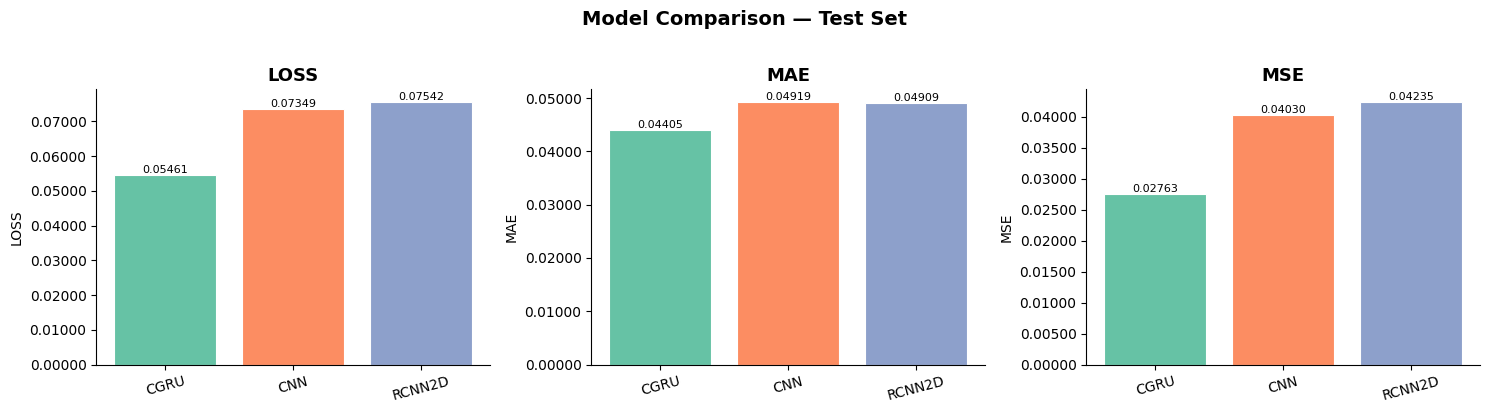

Figure saved → saves/eval_comparison.png


In [13]:
metrics_to_plot = ["LOSS", "MAE", "MSE"]
n_metrics = len(metrics_to_plot)

fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4), sharey=False)
colors = plt.cm.Set2(range(len(df)))  # type: ignore

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(df.index, df[metric], color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis="x", labelrotation=15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.5f}"))
    ax.spines[["top", "right"]].set_visible(False)
    # value labels
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, h,
            f"{h:.5f}", ha="center", va="bottom", fontsize=8
        )

fig.suptitle("Model Comparison — Test Set", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig("saves/eval_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → saves/eval_comparison.png")

## 9 · Visualise Predictions

For each model and each sample we show four rows:

| Row | Description |
|-----|-------------|
| **Input** | Context frames fed to the encoder |
| **Ground truth** | Target future frames |
| **Prediction** | Frames generated autoregressively |
| **\|Error\|** | Absolute pixel-wise difference (hot colormap) |

In [14]:
@torch.no_grad()
def collect_samples(
    model: torch.nn.Module,
    loader: DataLoader,
    n_samples: int,
    split_seq_len: int = SPLIT_SEQ_LEN,
    device: str = DEVICE,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Collect *n_samples* (inputs, labels, predictions) from *loader*.

    Returns tensors of shape (seq_len, N, C, H, W) on CPU.
    """
    all_inp, all_lbl, all_prd = [], [], []
    collected = 0

    for batch in loader:
        if collected >= n_samples:
            break
        inputs, labels = transpose_data(batch, split_seq_len)
        inputs = inputs.to(device)
        labels = labels.to(device)
        preds  = get_prediction(model, inputs, labels, teacher_forcing_ratio=0.0)

        take = min(n_samples - collected, inputs.shape[1])
        all_inp.append(inputs[:, :take].cpu())
        all_lbl.append(labels[:, :take].cpu())
        all_prd.append(preds[:, :take].cpu())
        collected += take

    return (
        torch.cat(all_inp, dim=1),
        torch.cat(all_lbl, dim=1),
        torch.cat(all_prd, dim=1),
    )


print("✅  collect_samples helper ready.")

✅  collect_samples helper ready.


In [15]:
def plot_sample(
    inp:   torch.Tensor,   # (in_len,  H, W)  – single sample, channel 0
    lbl:   torch.Tensor,   # (out_len, H, W)
    pred:  torch.Tensor,   # (out_len, H, W)
    title: str = "",
    colormap: str = "gray",
    dpi: int = 120,
) -> plt.Figure:
    """4-row grid: Input · Ground truth · Prediction · |Error|."""
    in_len  = inp.shape[0]
    out_len = lbl.shape[0]
    error   = (pred - lbl).abs()
    n_cols  = max(in_len, out_len)

    row_data = [
        (inp,   in_len,  "Input",        colormap, 0.0, 1.0),
        (lbl,   out_len, "Ground truth", colormap, 0.0, 1.0),
        (pred,  out_len, "Prediction",   colormap, 0.0, 1.0),
        (error, out_len, "|Error|",       "hot",    0.0, float(error.max()) or 1e-6),
    ]

    fig, axes = plt.subplots(
        4, n_cols,
        figsize=(max(n_cols * 1.2, 8), 4 * 1.4 + 0.5),
        dpi=dpi,
    )
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, (frames, length, label, cmap, vmin, vmax) in enumerate(row_data):
        for col in range(n_cols):
            ax = axes[row, col]
            if col < length:
                frame = frames[col].numpy()
                ax.imshow(frame, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
                t_label = col if row == 0 else col + in_len
                ax.set_title(f"t={t_label}", fontsize=7, pad=1)
                if row == 3:
                    ax.set_xlabel(f"μ|e|={frame.mean():.4f}", fontsize=6)
            else:
                ax.axis("off")
            ax.set_xticks([])
            ax.set_yticks([])
        axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=4, va="center")

    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)
    fig.tight_layout()
    return fig

print("✅  plot_sample helper ready.")

✅  plot_sample helper ready.



  Model: CGRU
  [cgru   ]  epoch= 49  params=555,905  ckpt=weights_cgru_best.pth


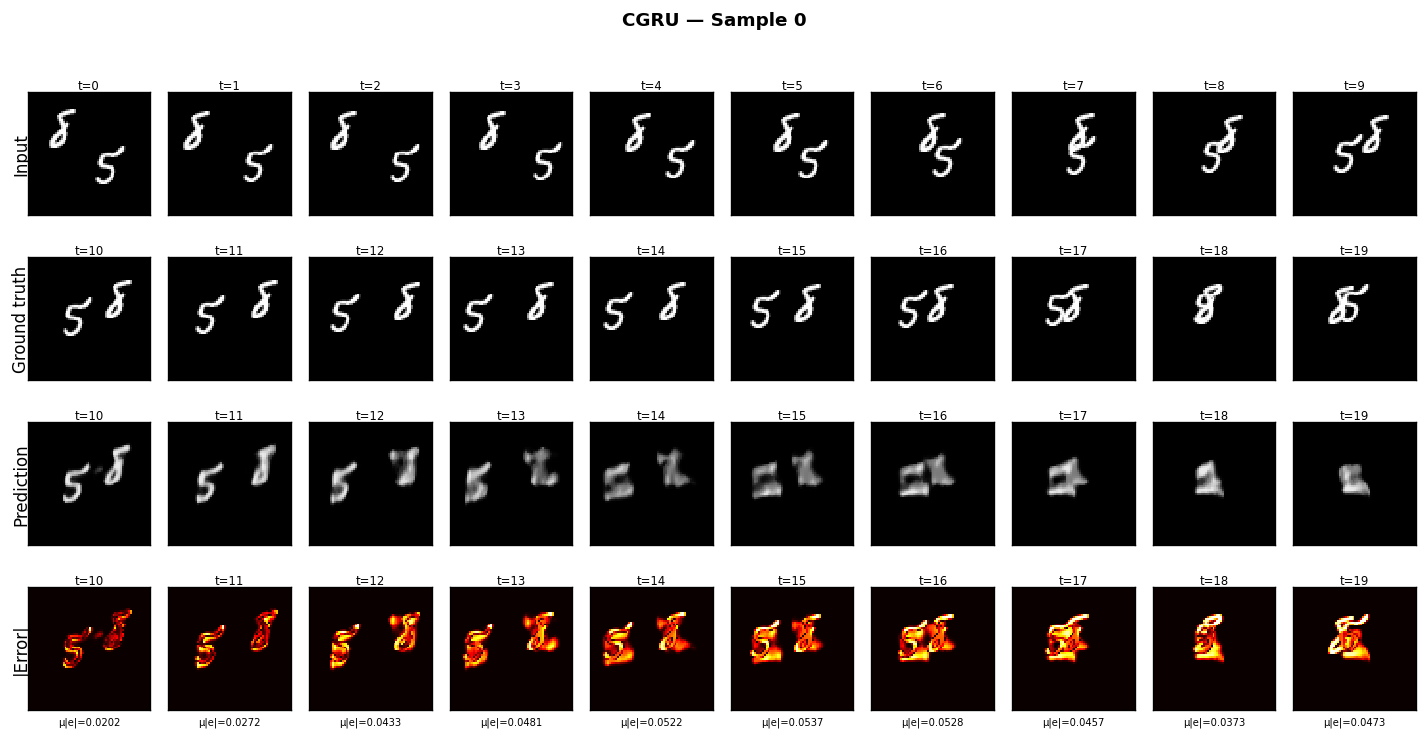

  Saved → saves/visualizations/cgru_sample_00.png


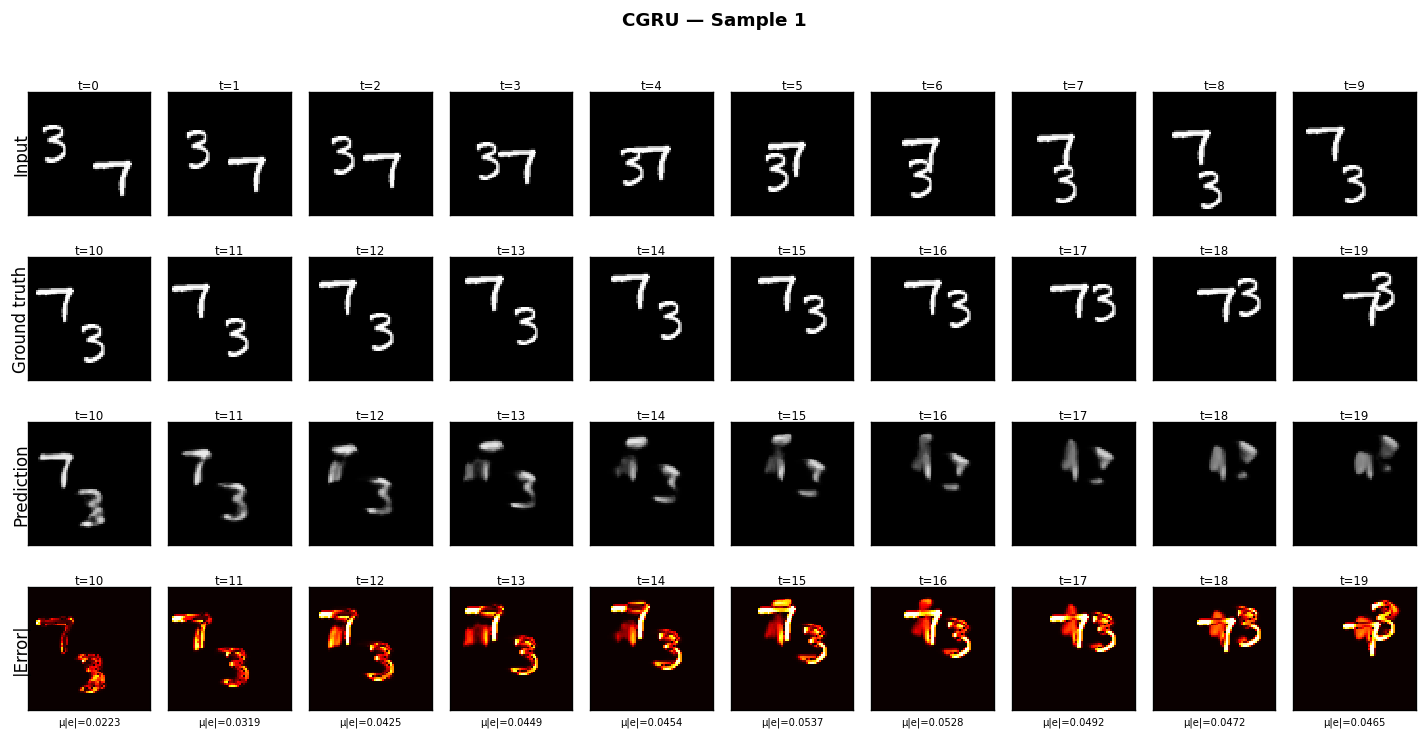

  Saved → saves/visualizations/cgru_sample_01.png


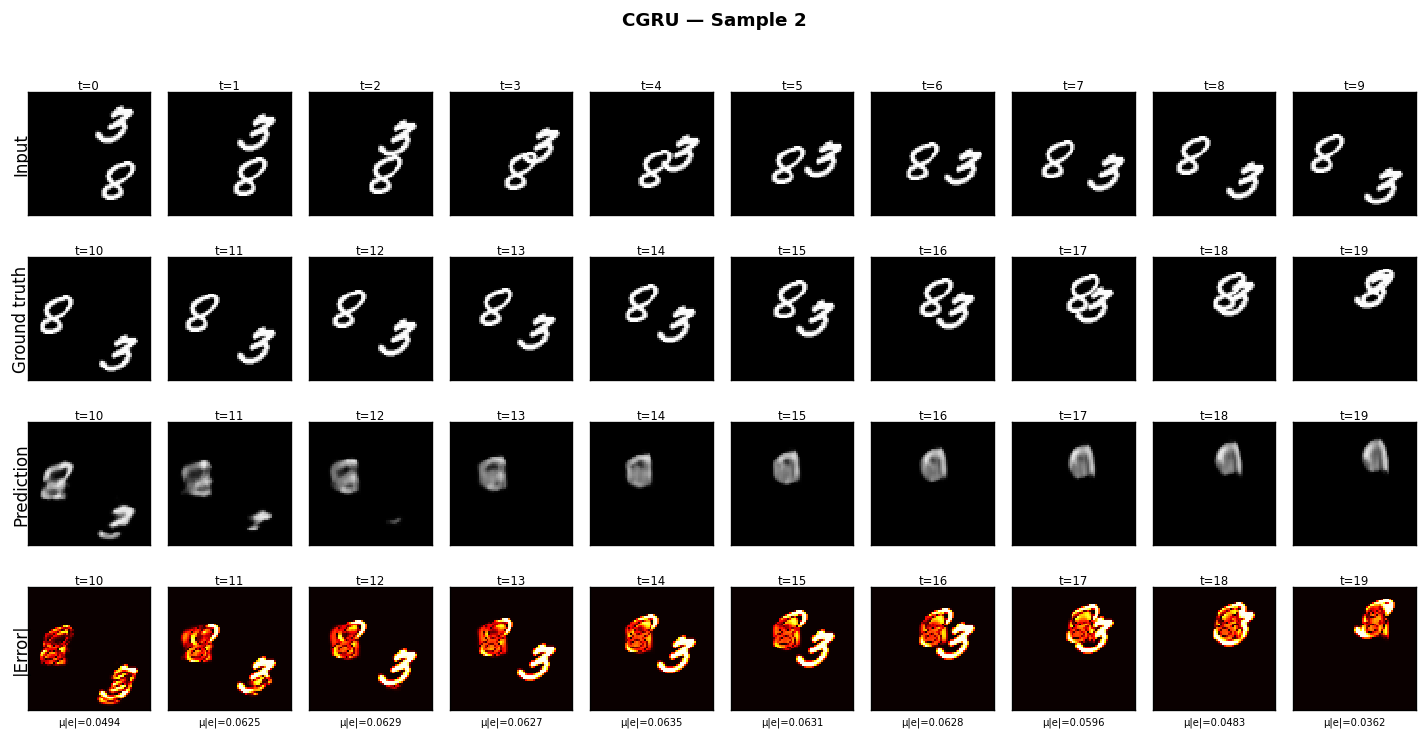

  Saved → saves/visualizations/cgru_sample_02.png


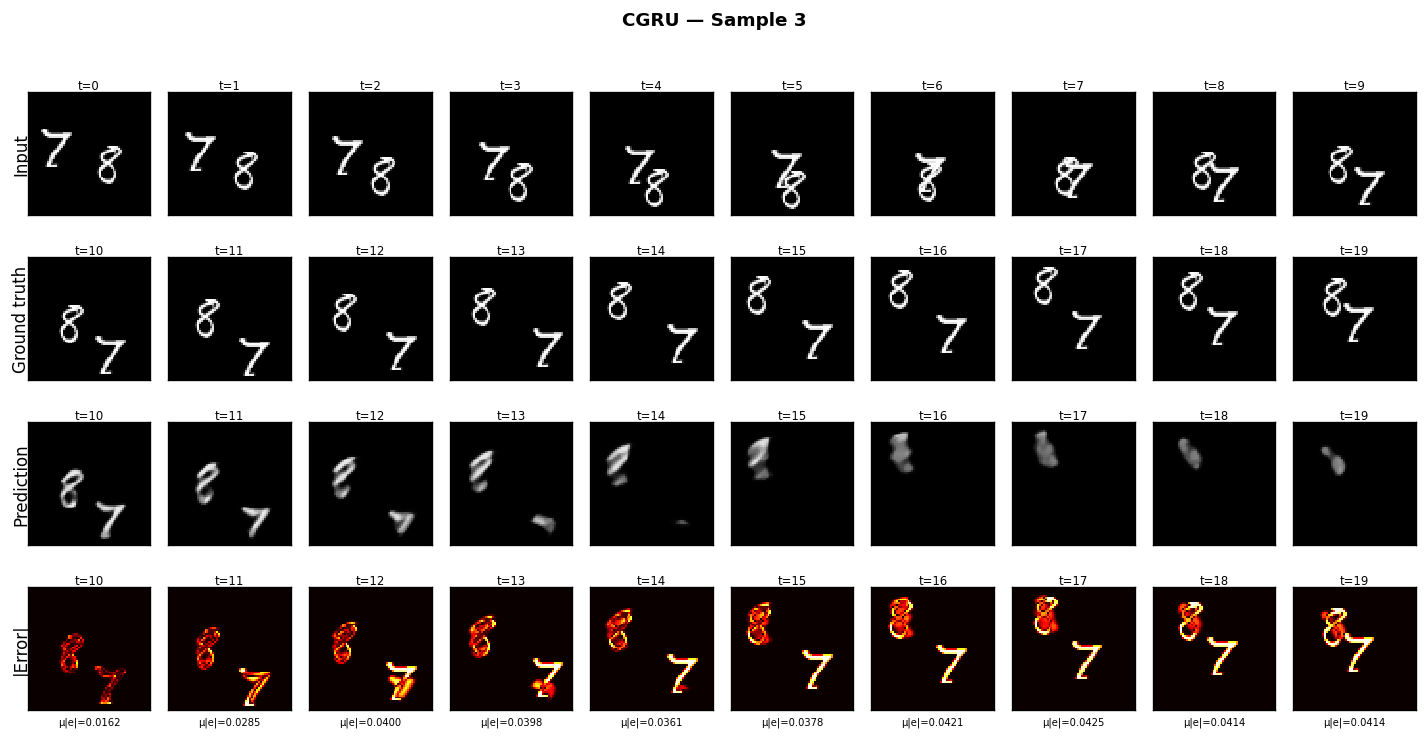

  Saved → saves/visualizations/cgru_sample_03.png

  Model: CNN
  [cnn    ]  epoch= 47  params=74,561  ckpt=weights_cnn_best.pth


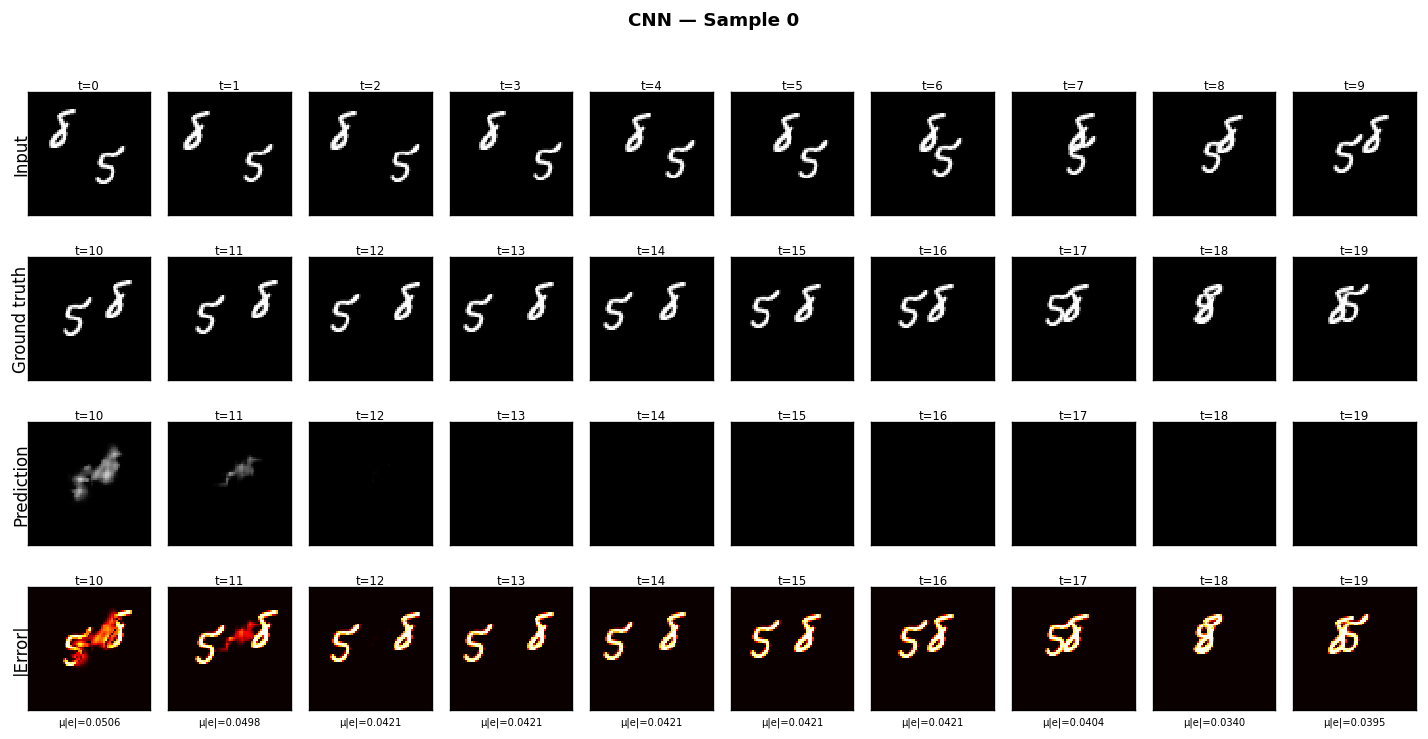

  Saved → saves/visualizations/cnn_sample_00.png


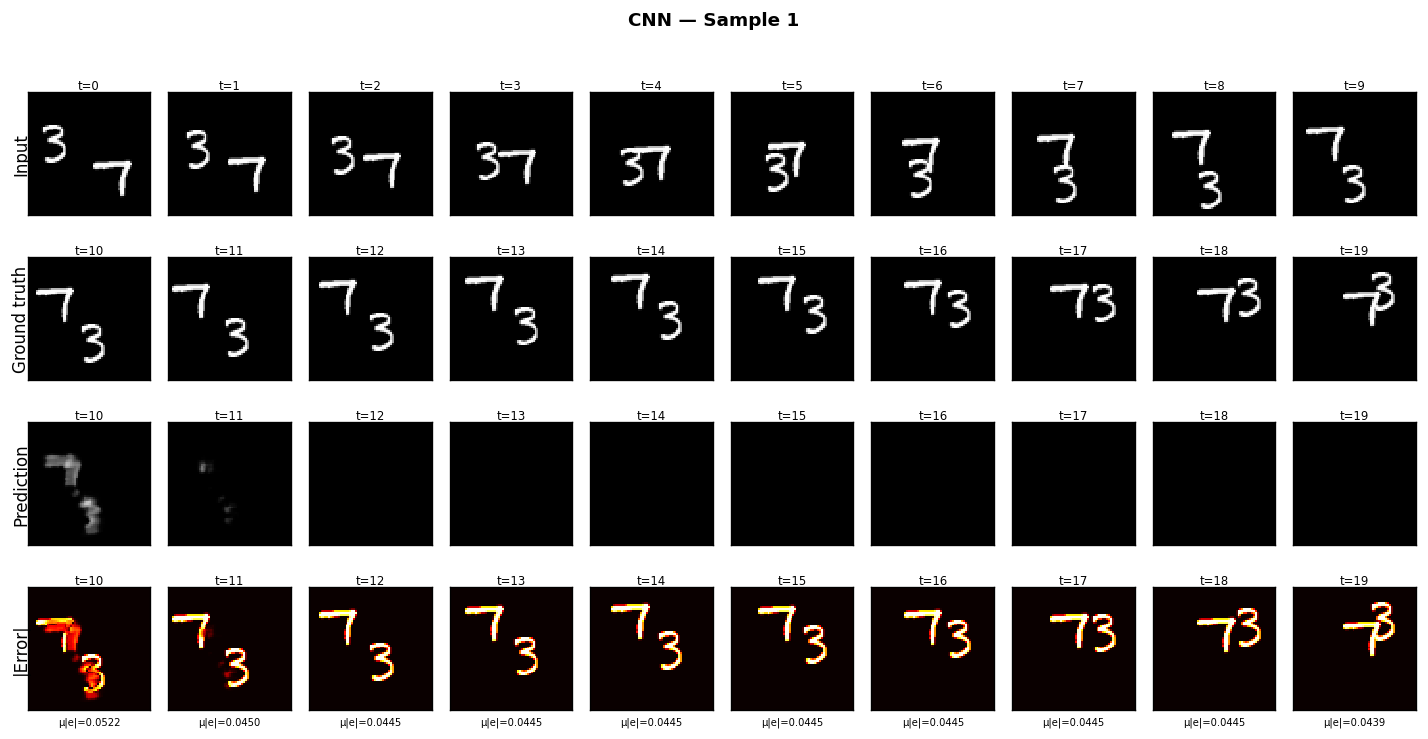

  Saved → saves/visualizations/cnn_sample_01.png


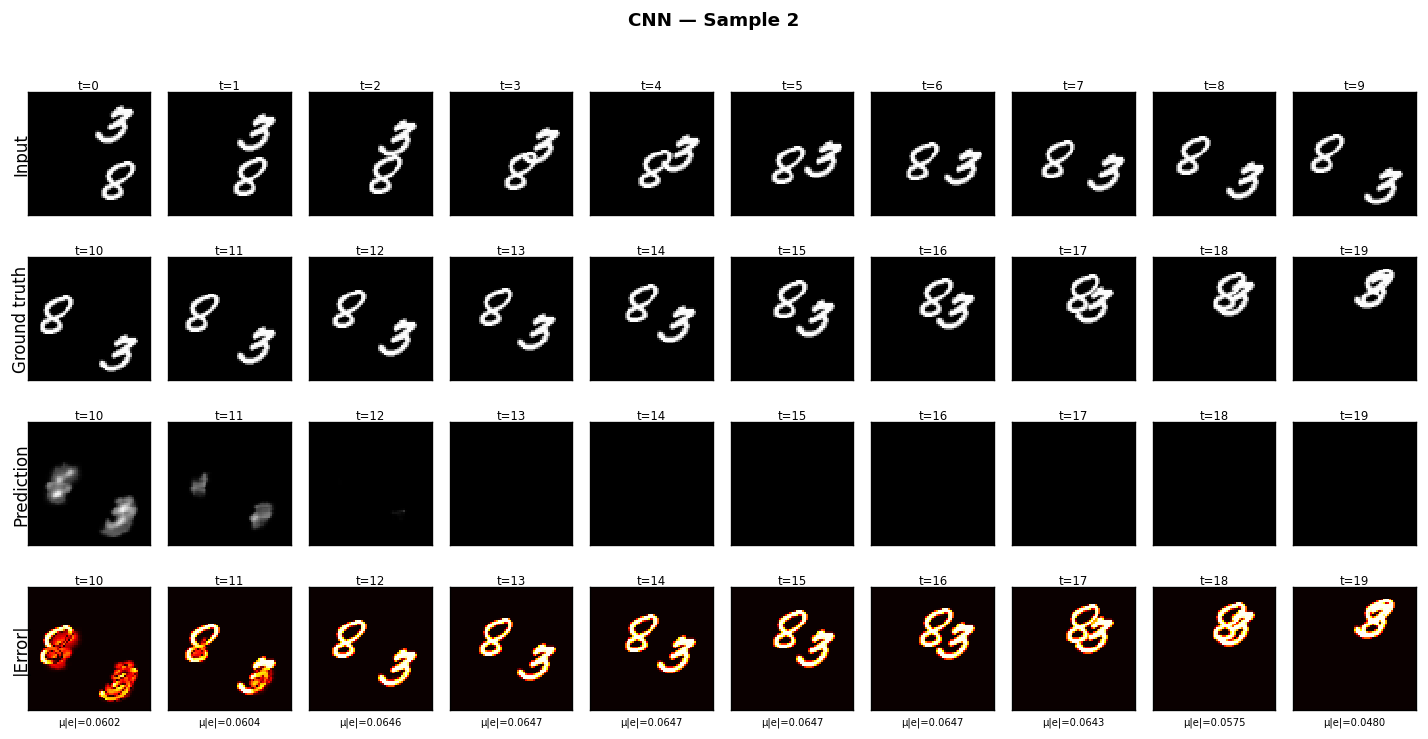

  Saved → saves/visualizations/cnn_sample_02.png


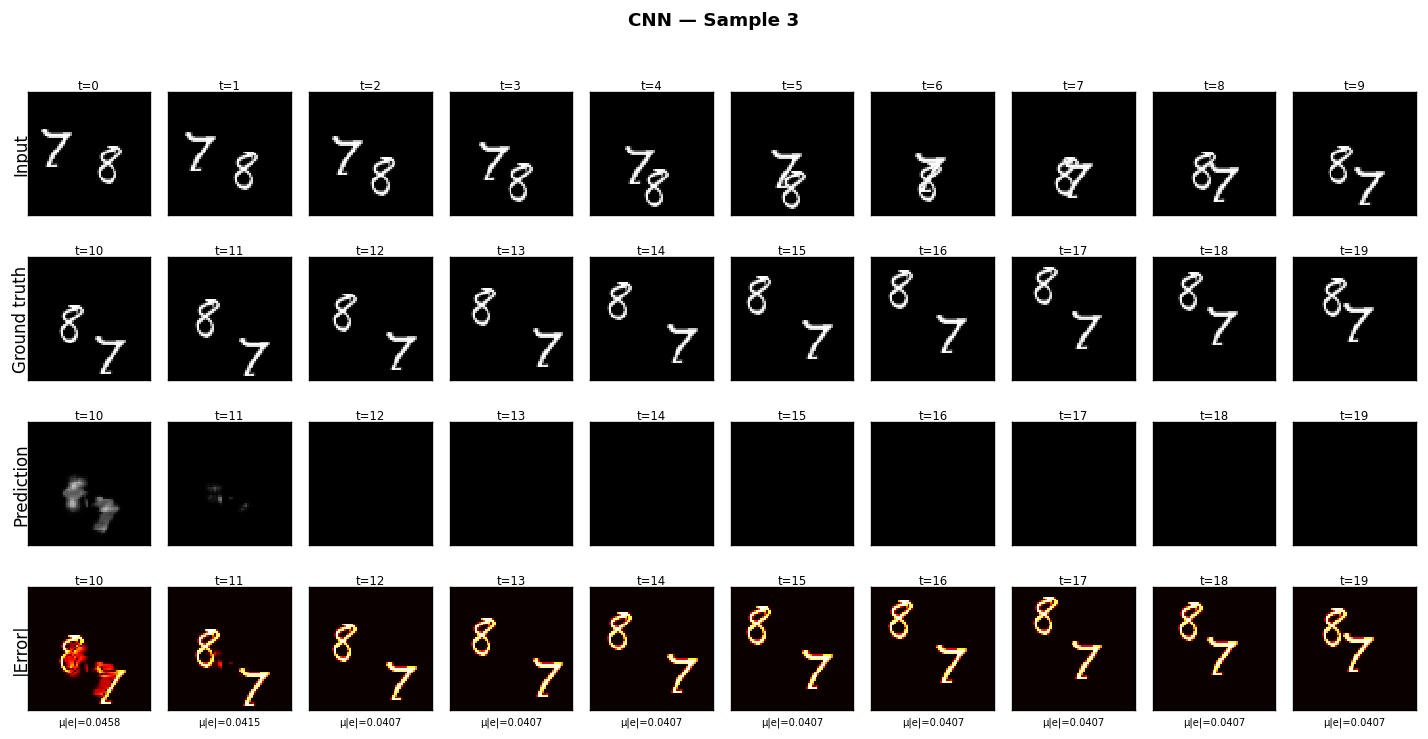

  Saved → saves/visualizations/cnn_sample_03.png

  Model: RCNN2D
  [rcnn2d ]  epoch= 21  params=185,345  ckpt=weights_rcnn2d_best.pth


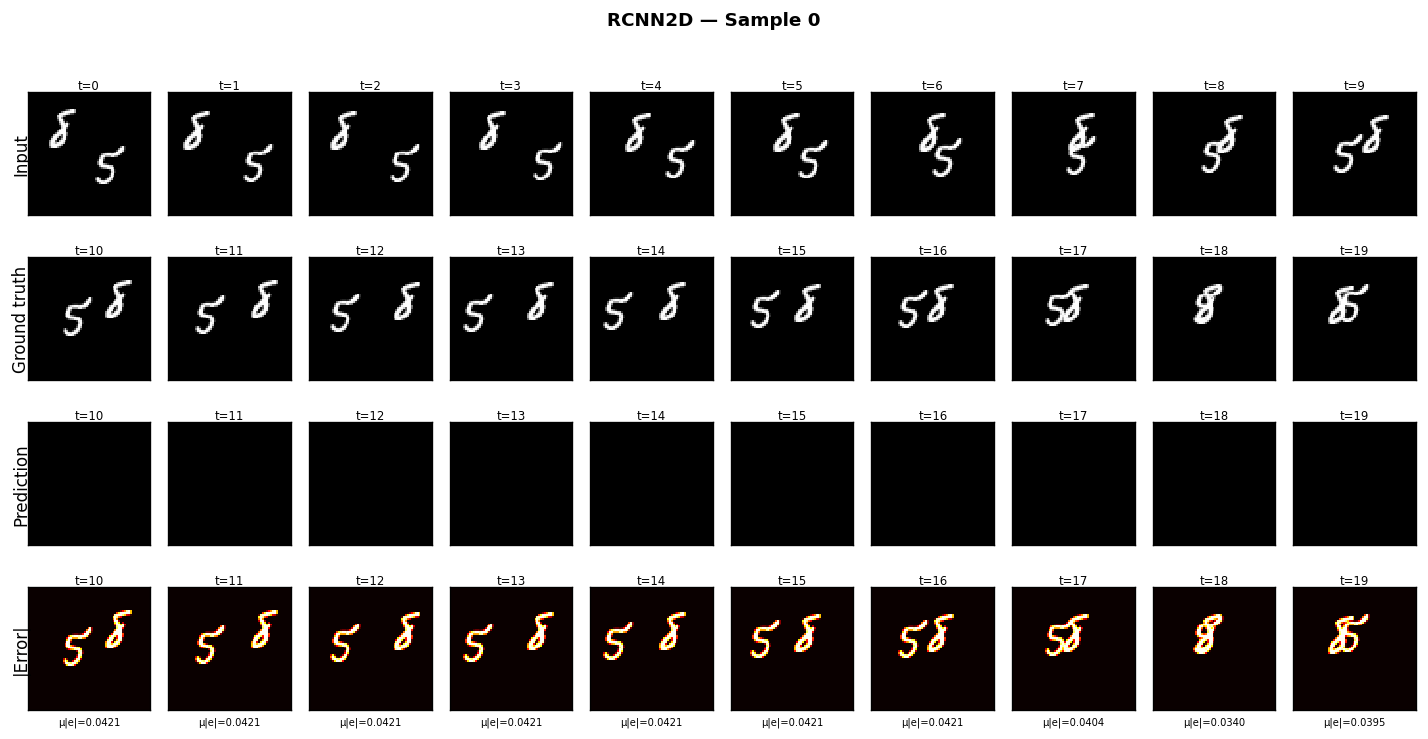

  Saved → saves/visualizations/rcnn2d_sample_00.png


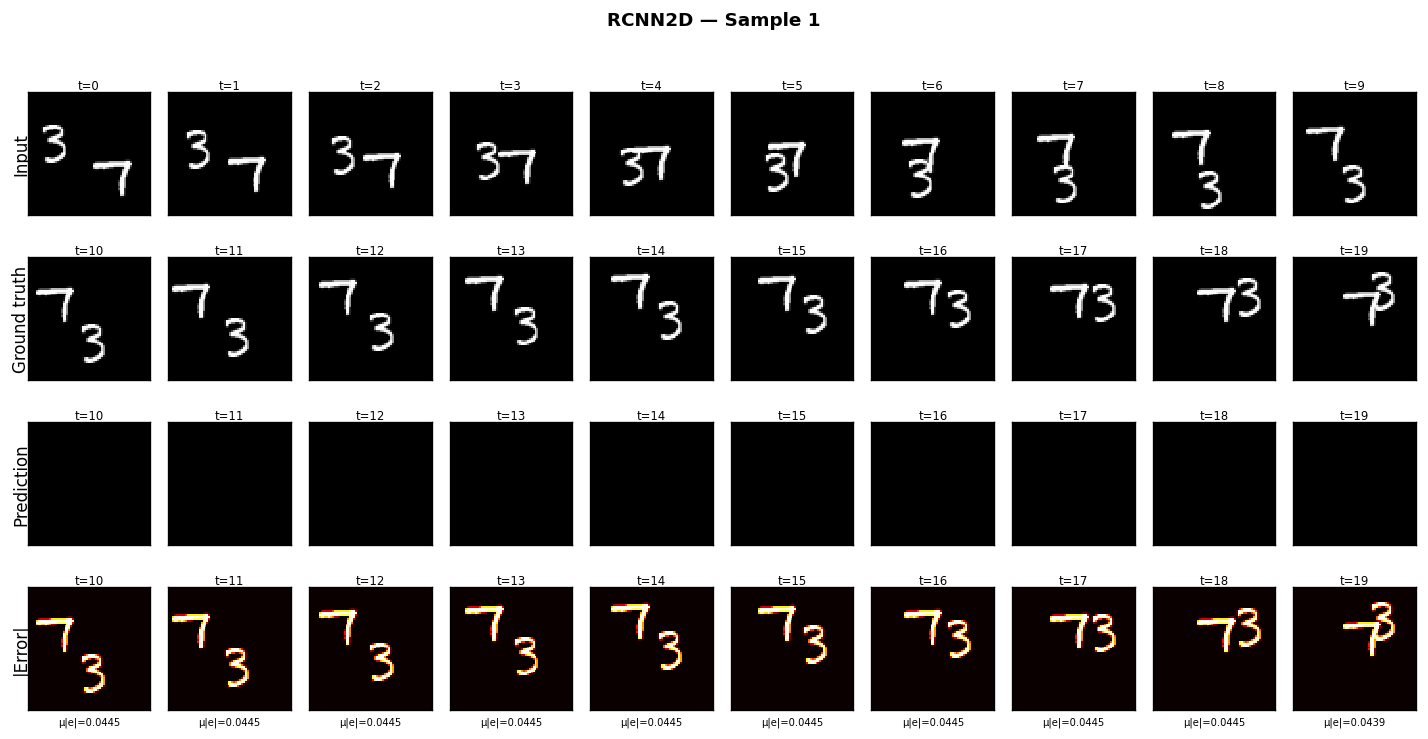

  Saved → saves/visualizations/rcnn2d_sample_01.png


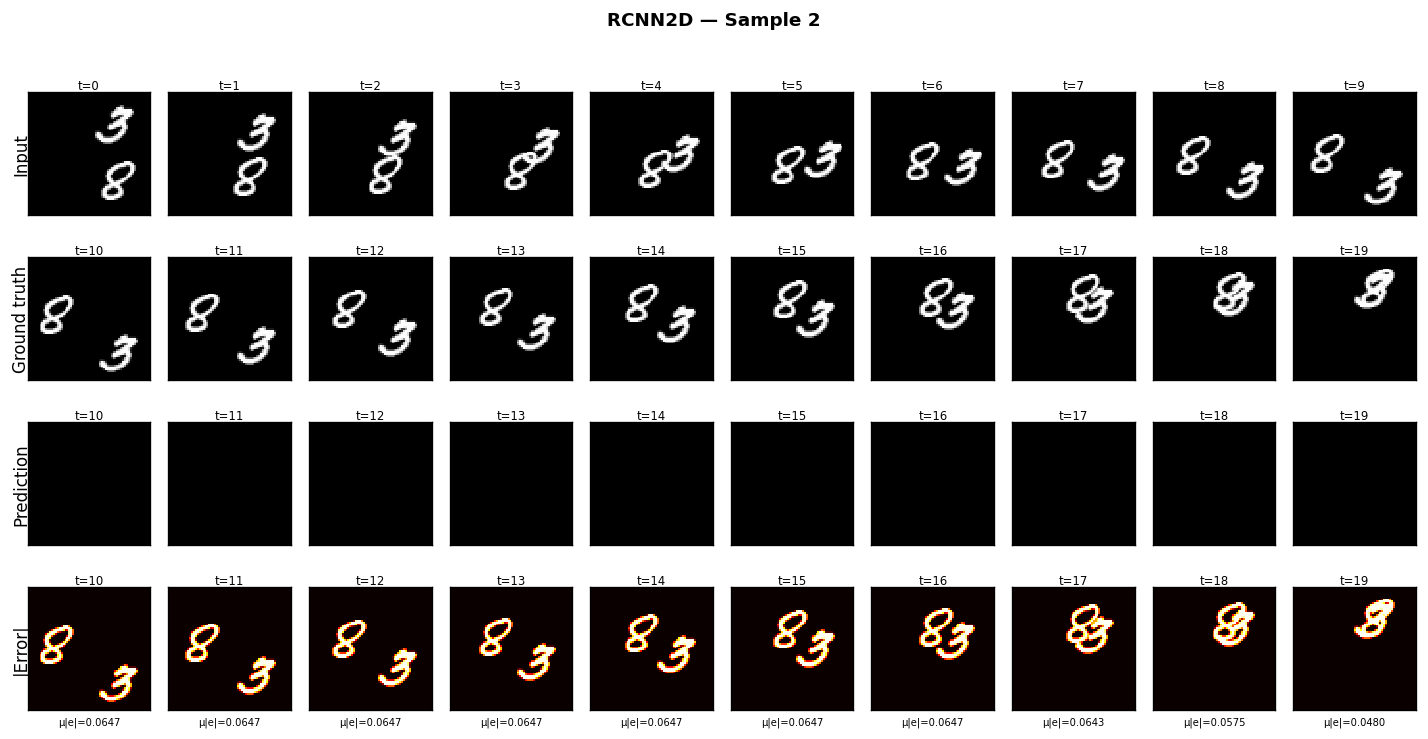

  Saved → saves/visualizations/rcnn2d_sample_02.png


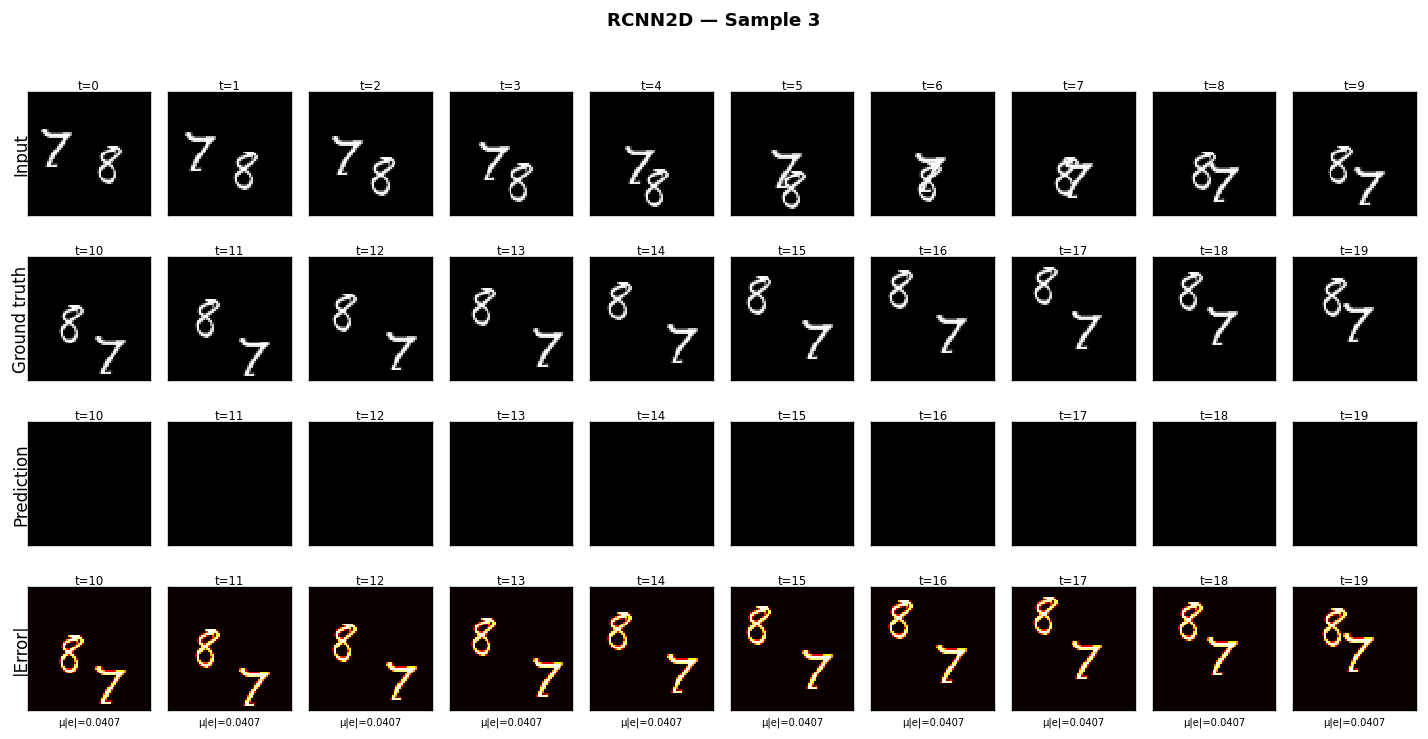

  Saved → saves/visualizations/rcnn2d_sample_03.png

✅  Visualisation complete.


In [16]:
import os

VIZ_DIR = Path("saves/visualizations")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Use the first N_VIZ_SAMPLES sequences from the test loader (reproducible)
_viz_ds = MovingMNISTDataset(TEST_NPY)
_viz_dl = make_dataloader(_viz_ds, batch_size=N_VIZ_SAMPLES, train=False, n_workers=0)

for mtype, ckpt_path in checkpoints.items():
    print(f"\n{'='*60}")
    print(f"  Model: {mtype.upper()}")
    print(f"{'='*60}")

    model, loss_fn = load_model(mtype, ckpt_path)
    inp_t, lbl_t, prd_t = collect_samples(
        model, _viz_dl, n_samples=N_VIZ_SAMPLES
    )
    # inp_t: (in_len,  N, 1, H, W)
    # lbl_t: (out_len, N, 1, H, W)
    # prd_t: (out_len, N, 1, H, W)

    for idx in range(N_VIZ_SAMPLES):
        inp  = inp_t[:, idx, 0]   # (in_len,  H, W)
        lbl  = lbl_t[:, idx, 0]   # (out_len, H, W)
        pred = prd_t[:, idx, 0]   # (out_len, H, W)

        fig = plot_sample(
            inp, lbl, pred,
            title=f"{mtype.upper()} — Sample {idx}",
        )
        save_path = VIZ_DIR / f"{mtype}_sample_{idx:02d}.png"
        fig.savefig(save_path, dpi=120, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"  Saved → {save_path}")

print("\n✅  Visualisation complete.")

## 10 · Per-Frame Error Over Time

Shows how MAE grows as the model predicts further into the future (auto-regressive error accumulation).

  [cgru   ]  epoch= 49  params=555,905  ckpt=weights_cgru_best.pth
  [cnn    ]  epoch= 47  params=74,561  ckpt=weights_cnn_best.pth
  [rcnn2d ]  epoch= 21  params=185,345  ckpt=weights_rcnn2d_best.pth


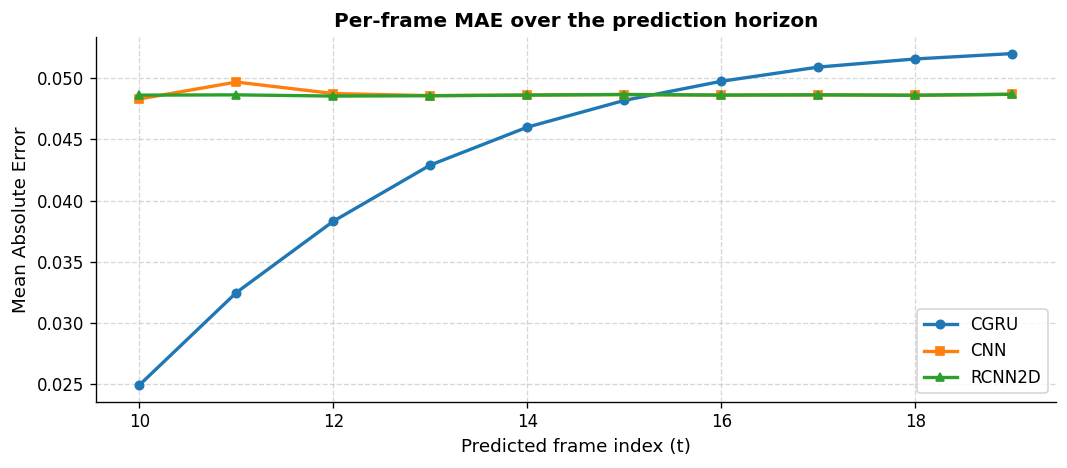

Saved → saves/visualizations/per_frame_mae.png


In [17]:
@torch.no_grad()
def per_frame_mae(
    model: torch.nn.Module,
    loader: DataLoader,
    split_seq_len: int = SPLIT_SEQ_LEN,
    device: str = DEVICE,
    max_batches: int = 20,
) -> np.ndarray:
    """Return mean MAE per predicted frame, averaged over `max_batches` batches."""
    accum = None
    count = 0

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break
        inputs, labels = transpose_data(batch, split_seq_len)
        inputs = inputs.to(device)
        labels = labels.to(device)
        preds  = get_prediction(model, inputs, labels, teacher_forcing_ratio=0.0)

        # MAE per time-step: mean over (batch, C, H, W)
        frame_mae = (preds - labels).abs().mean(dim=(1, 2, 3, 4)).cpu().numpy()
        # shape: (out_len,)

        if accum is None:
            accum = frame_mae
        else:
            accum += frame_mae
        count += 1

    return accum / count if count > 0 else np.zeros(1)


# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4), dpi=120)
markers = ["o", "s", "^", "D"]

for (mtype, ckpt_path), marker in zip(checkpoints.items(), markers):
    model, _ = load_model(mtype, ckpt_path)
    mae_curve = per_frame_mae(model, test_dl)

    t_steps = np.arange(SPLIT_SEQ_LEN, SPLIT_SEQ_LEN + len(mae_curve))
    ax.plot(
        t_steps, mae_curve,
        marker=marker, markersize=5, label=mtype.upper(), linewidth=2
    )

ax.set_xlabel("Predicted frame index (t)", fontsize=11)
ax.set_ylabel("Mean Absolute Error", fontsize=11)
ax.set_title("Per-frame MAE over the prediction horizon", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

save_path = VIZ_DIR / "per_frame_mae.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path}")

## 11 · Export All Results

Collect everything into a single CSV and print a final summary.

In [18]:
import csv, datetime

OUT_CSV = VIZ_DIR / f"eval_results_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"

with OUT_CSV.open("w", newline="", encoding="utf-8") as f:
    fieldnames = ["model", "loss", "mae", "mse"]
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for mtype, scores in eval_results.items():
        writer.writerow({"model": mtype, **scores})

print(f"Results CSV → {OUT_CSV}")
print("\n── Final Summary ──────────────────────────────────────")
print(f"{'Model':>8}  {'Loss':>10}  {'MAE':>10}  {'MSE':>10}")
print("-" * 45)
for mtype, scores in eval_results.items():
    print(
        f"{mtype.upper():>8}  "
        f"{scores['loss']:>10.6f}  "
        f"{scores['mae']:>10.6f}  "
        f"{scores['mse']:>10.6f}"
    )

best_model = min(eval_results, key=lambda m: eval_results[m]["loss"])
print(f"\n🏆  Best model: {best_model.upper()}  "
      f"(loss = {eval_results[best_model]['loss']:.6f})")

Results CSV → saves/visualizations/eval_results_20260514_022737.csv

── Final Summary ──────────────────────────────────────
   Model        Loss         MAE         MSE
---------------------------------------------
    CGRU    0.054606    0.044050    0.027633
     CNN    0.073487    0.049187    0.040302
  RCNN2D    0.075423    0.049090    0.042353

🏆  Best model: CGRU  (loss = 0.054606)


---

### 📁 Output Files

All artefacts are written to `saves/`:

| File | Description |
|------|-------------|
| `saves/eval_comparison.png` | Bar-chart comparison across models |
| `saves/visualizations/{model}_sample_XX.png` | Per-model per-sample prediction grids |
| `saves/visualizations/side_by_side.png` | One-frame side-by-side comparison |
| `saves/visualizations/per_frame_mae.png` | MAE over the prediction horizon |
| `saves/visualizations/eval_results_*.csv` | Numeric results (importable into a spreadsheet) |

To download them, right-click any file in the Colab file browser on the left, or zip the whole folder:

```python
# Run this cell to zip everything and download
import shutil
shutil.make_archive('rcnn_results', 'zip', 'saves')
from google.colab import files
files.download('rcnn_results.zip')
```
